# Exploratory Data Analysis: MAESTRO MIDI

Library Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import librosa
import librosa.display
import pretty_midi
from collections import Counter, defaultdict
from IPython.display import Audio
from music21 import converter
from music21 import stream, clef, note, chord


Path to dataset

In [ ]:
maestro_path = Path("../data/raw/maestro-v3.0.0")  
sample_audio_folder = maestro_path / "2004" # A sample dataset is chosen to contain a small set for data exploration

Plot styles

In [5]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# For high-res plots
%config InlineBackend.figure_format = 'retina'

Number of files

In [6]:
files = os.listdir(sample_audio_folder)

wav_files = sorted([f for f in files if f.endswith(".wav")])
midi_files = sorted([f for f in files if f.endswith(".midi")])

print(f"WAV files: {len(wav_files)}")
print(f"MIDI files: {len(midi_files)}")

WAV files: 132
MIDI files: 132


In [7]:
midi_file = "raw/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi"  
midi = pretty_midi.PrettyMIDI(midi_file)

In [9]:
df = pd.read_csv('../data/raw/maestro-v3.0.0/maestro-v3.0.0.csv')

Select one audio file from each set (train, validation and test)

In [10]:
# Filter only year 2004
df_2004 = df[df['year'] == 2004]

# Select a few representative audio files (one per split)
sample_files = []

for split in ['train', 'validation', 'test']:
    split_df = df_2004[df_2004['split'] == split]
    
    if len(split_df) == 0:
        continue  # In case a split doesn't exist in 2004
    
    # Pick recording closest to median duration
    median_duration = split_df['duration'].median()
    closest = split_df.iloc[
        (split_df['duration'] - median_duration).abs().argsort()[:1]
    ]
    
    sample_files.append(closest.iloc[0])


print("Selected sample files for analysis (Year 2004):\n")

for i, sample in enumerate(sample_files, 1):
    print(f"{i}. Split: {sample['split']:12s} | "
          f"Duration: {sample['duration']:6.1f}s")
    print(f"   Composer: {sample['canonical_composer']}")
    print(f"   File: {sample['audio_filename']}\n")


Selected sample files for analysis (Year 2004):

1. Split: train        | Duration:  563.9s
   Composer: Ludwig van Beethoven
   File: 2004/MIDI-Unprocessed_SMF_17_R1_2004_01-03_ORIG_MID--AUDIO_17_R1_2004_03_Track03_wav.wav

2. Split: validation   | Duration:  321.4s
   Composer: Sergei Rachmaninoff
   File: 2004/MIDI-Unprocessed_SMF_16_R1_2004_01-08_ORIG_MID--AUDIO_16_R1_2004_03_Track03_wav.wav

3. Split: test         | Duration:  249.1s
   Composer: Franz Schubert / Franz Liszt
   File: 2004/MIDI-Unprocessed_XP_18_R1_2004_01-02_ORIG_MID--AUDIO_18_R1_2004_05_Track05_wav.wav



Visualization of the waveform

/Users/miguel/Desktop/TFG/TFG_Automatic_Music_Transcription/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


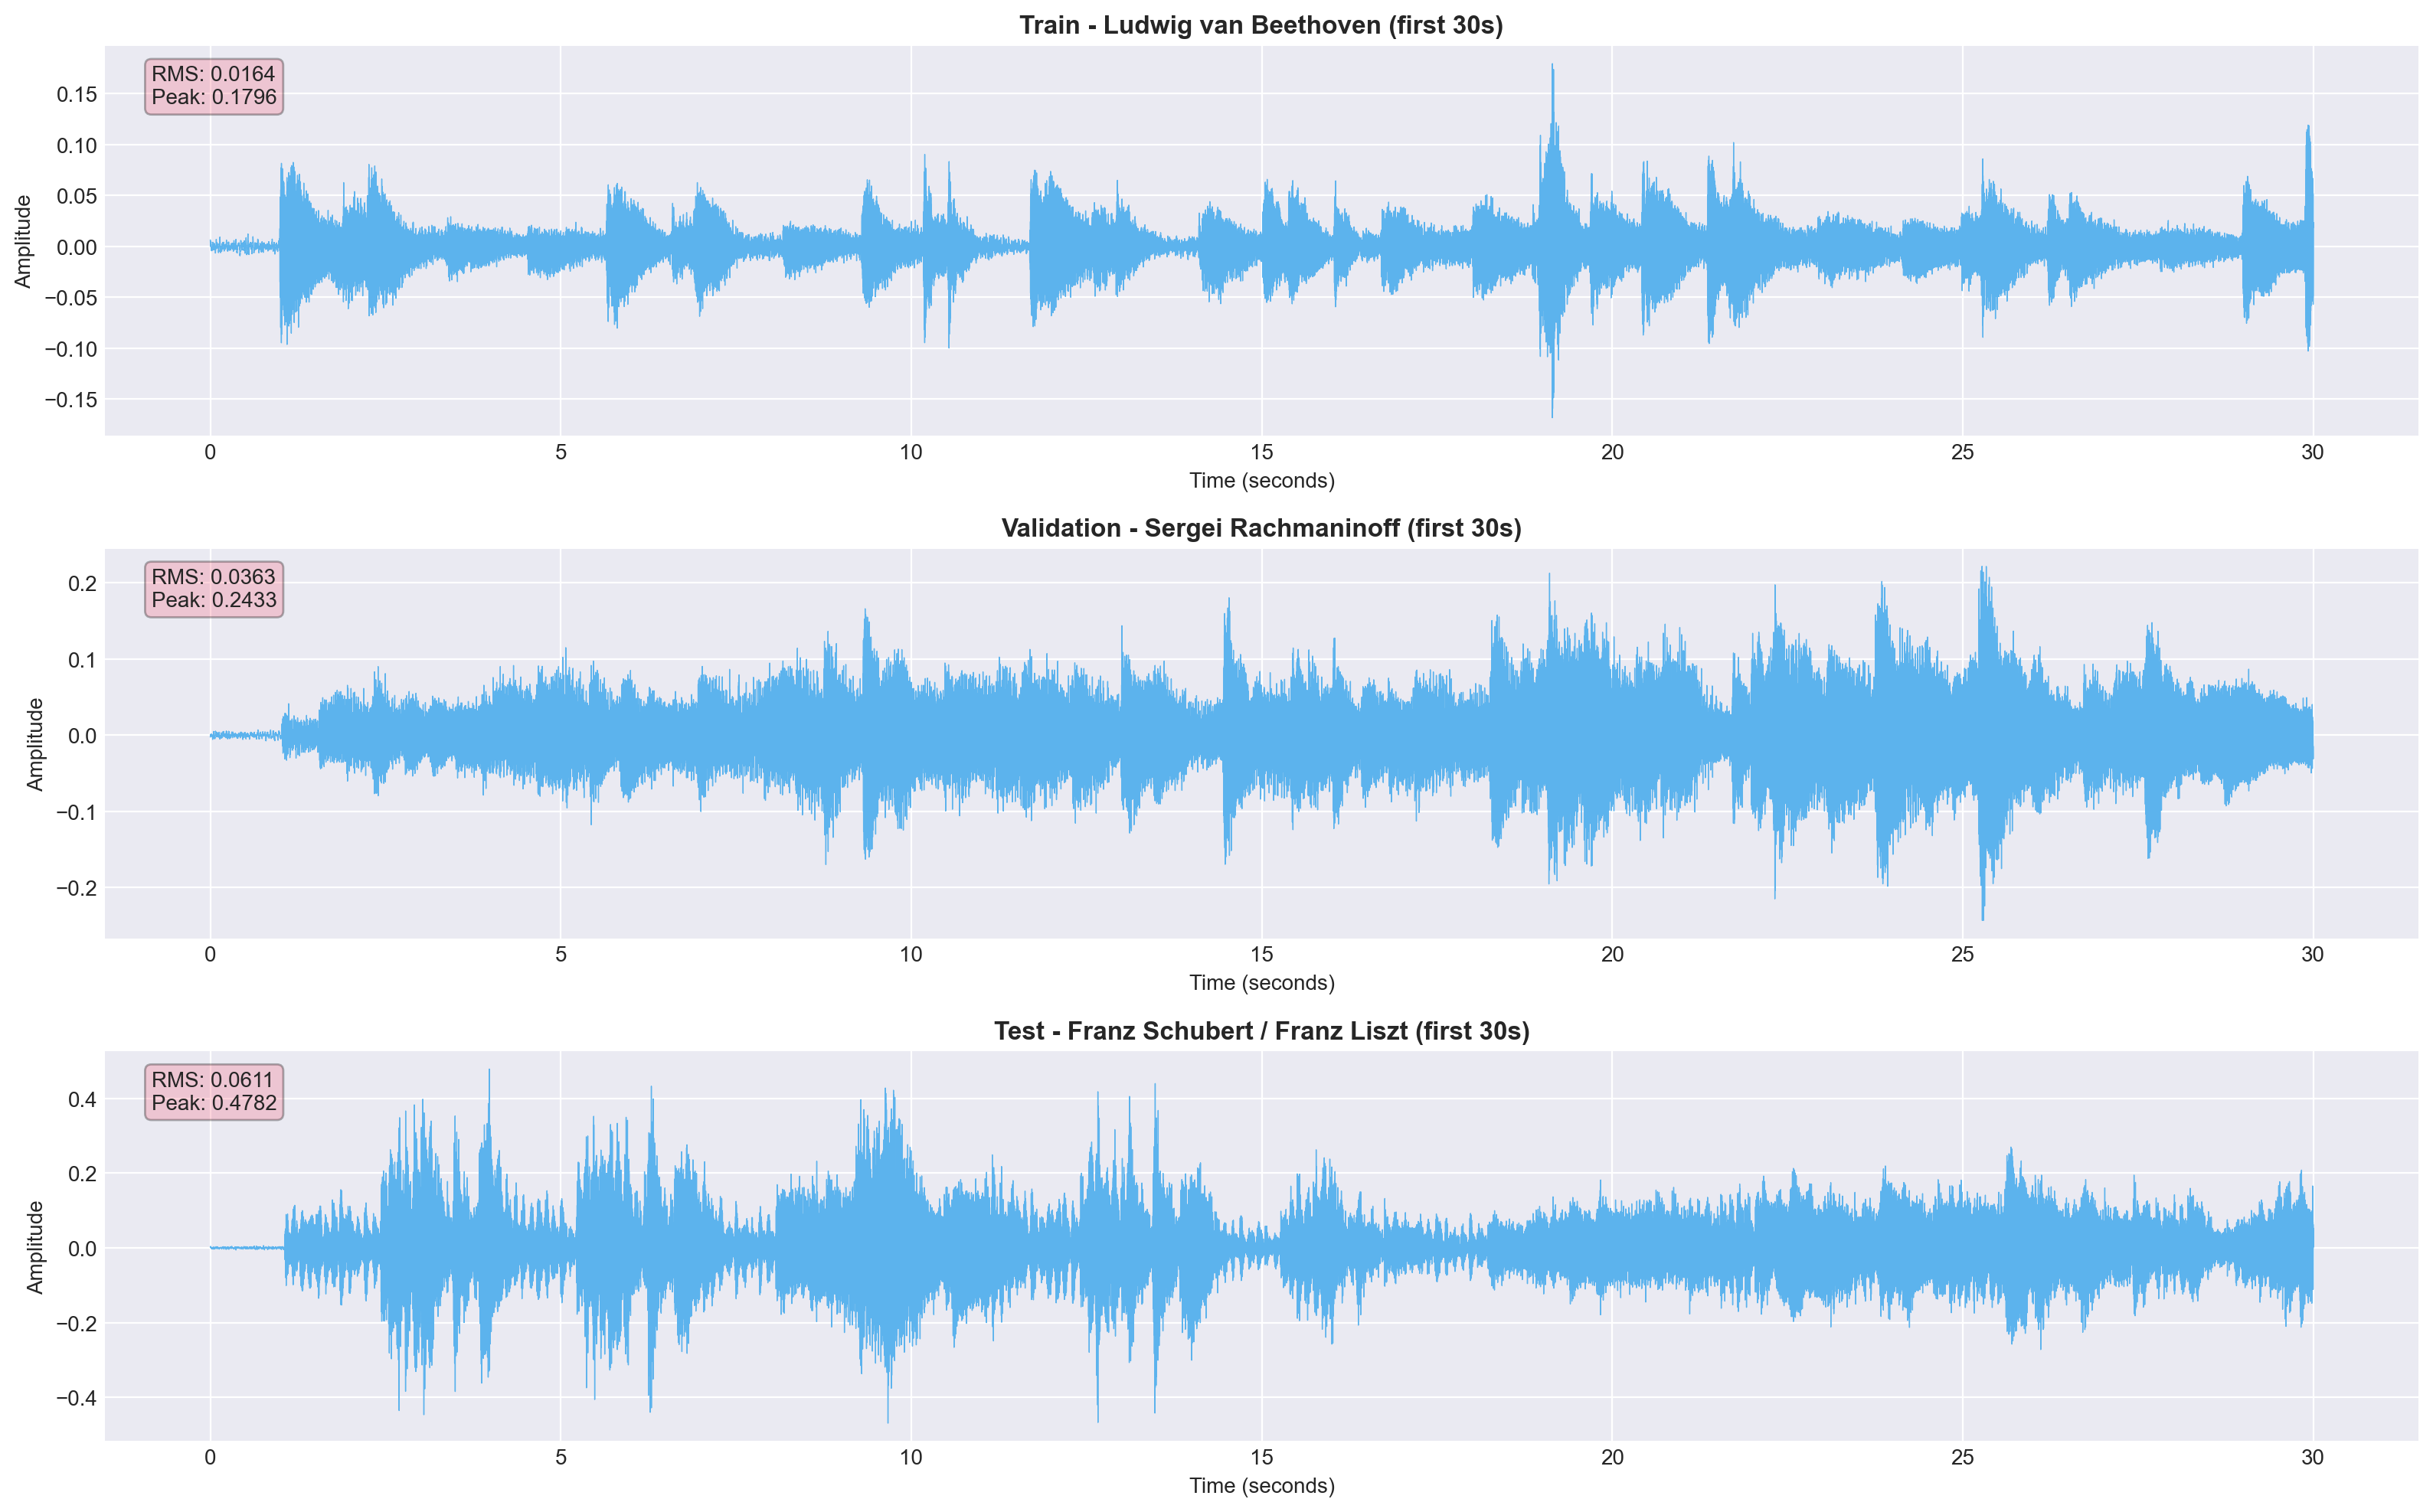

In [11]:

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

for sample, ax in zip(sample_files, axes):
    audio_path = maestro_path / sample['audio_filename']
    
    if audio_path.exists():
        # Load first 30 seconds
        y, sr = librosa.load(audio_path, sr=16000, duration=30)
        time = np.arange(len(y)) / sr
        
        # Use seaborn lineplot
        sns.lineplot(
            x=time,
            y=y,
            ax=ax,
            linewidth=0.5, 
            color = "#5cb3ed"
        )
        
        ax.set_title(
            f"{sample['split'].capitalize()} - {sample['canonical_composer']} (first 30s)",
            fontweight='bold'
        )
        ax.set_xlabel('Time (seconds)')
        ax.set_ylabel('Amplitude')
        
        # Stats
        rms = np.sqrt(np.mean(y**2))
        peak = np.max(np.abs(y))
        
        ax.text(
            0.02, 0.95,
            f'RMS: {rms:.4f}\nPeak: {peak:.4f}',
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', alpha=0.3)
        )
        
    else:
        ax.text(0.5, 0.5, 'Audio file not found',
                ha='center', va='center')
        ax.set_title(f"{sample['split'].capitalize()} - File not found")

plt.tight_layout()
plt.show()


Sound of the audio

In [12]:
# First sample
sample = sample_files[0]
audio_path = maestro_path / sample['audio_filename']
y, sr = librosa.load(audio_path, sr=16000, duration=30)

Audio(y, rate=sr)

Adding noise to test

In [13]:
def add_noise_snr(signal, snr_db):
    rms_signal = np.sqrt(np.mean(signal**2))
    
    # Convert SNR from dB
    snr_linear = 10**(snr_db / 20)
    
    rms_noise = rms_signal / snr_linear
    noise = np.random.randn(len(signal))
    noise = noise / np.sqrt(np.mean(noise**2))  # normalize noise
    
    noisy_signal = signal + rms_noise * noise
    return np.clip(noisy_signal, -1.0, 1.0)


Sound of the degraded audio file


In [14]:
y_noisy = add_noise_snr(y, snr_db=20)  # 20 dB = light noise
Audio(y_noisy, rate=sr)

Plotting Spectrograms (CQT, Mel, STFT)

In [36]:
def plot_spectograms(audio_path, noise_db=0):
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'text.color': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
    })
    if not audio_path.exists():
        print("Audio file not found.")
        return

    y, sr = librosa.load(audio_path, sr=16000, duration=5)

    if noise_db:
        y = add_noise_snr(y, noise_db)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    TITLE_SIZE = 20
    LABEL_SIZE = 18
    TICK_SIZE = 10

    # 1. STFT
    D = librosa.stft(y)
    D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    sns.heatmap(D_db, ax=axes[0], cmap="magma", cbar=True,
                cbar_kws={"shrink": 0.8, "pad": 0.02})
    axes[0].set_title("STFT\n(Linear Frequency)", fontsize=TITLE_SIZE)
    axes[0].set_ylabel("Frequency Bin", fontsize=LABEL_SIZE)
    axes[0].set_xlabel("Time Frame", fontsize=LABEL_SIZE)
    axes[0].tick_params(labelsize=TICK_SIZE)

    # 2. Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    sns.heatmap(mel_db, ax=axes[1], cmap="magma", cbar=True,
                cbar_kws={"shrink": 0.8, "pad": 0.02})
    axes[1].set_title("Mel Spectrogram\n(Perceptual Scale)", fontsize=TITLE_SIZE)
    axes[1].set_ylabel("Mel Bin", fontsize=LABEL_SIZE)
    axes[1].set_xlabel("Time Frame", fontsize=LABEL_SIZE)
    axes[1].tick_params(labelsize=TICK_SIZE)

    # 3. CQT
    cqt = librosa.cqt(y, sr=sr, n_bins=252, bins_per_octave=36)
    cqt_db = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)
    sns.heatmap(cqt_db, ax=axes[2], cmap="magma", cbar=True,
                cbar_kws={"shrink": 0.8, "pad": 0.02})
    axes[2].set_title("CQT Spectrogram\n(Musical Scale)", fontsize=TITLE_SIZE)
    axes[2].set_ylabel("CQT Bin", fontsize=LABEL_SIZE)
    axes[2].set_xlabel("Time Frame", fontsize=LABEL_SIZE)
    axes[2].tick_params(labelsize=TICK_SIZE)

    plt.tight_layout(pad=1.5)

    fig.savefig(
        "../images/spectrograms.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"  # prevents transparent background in Word/slides
    )

    plt.show()

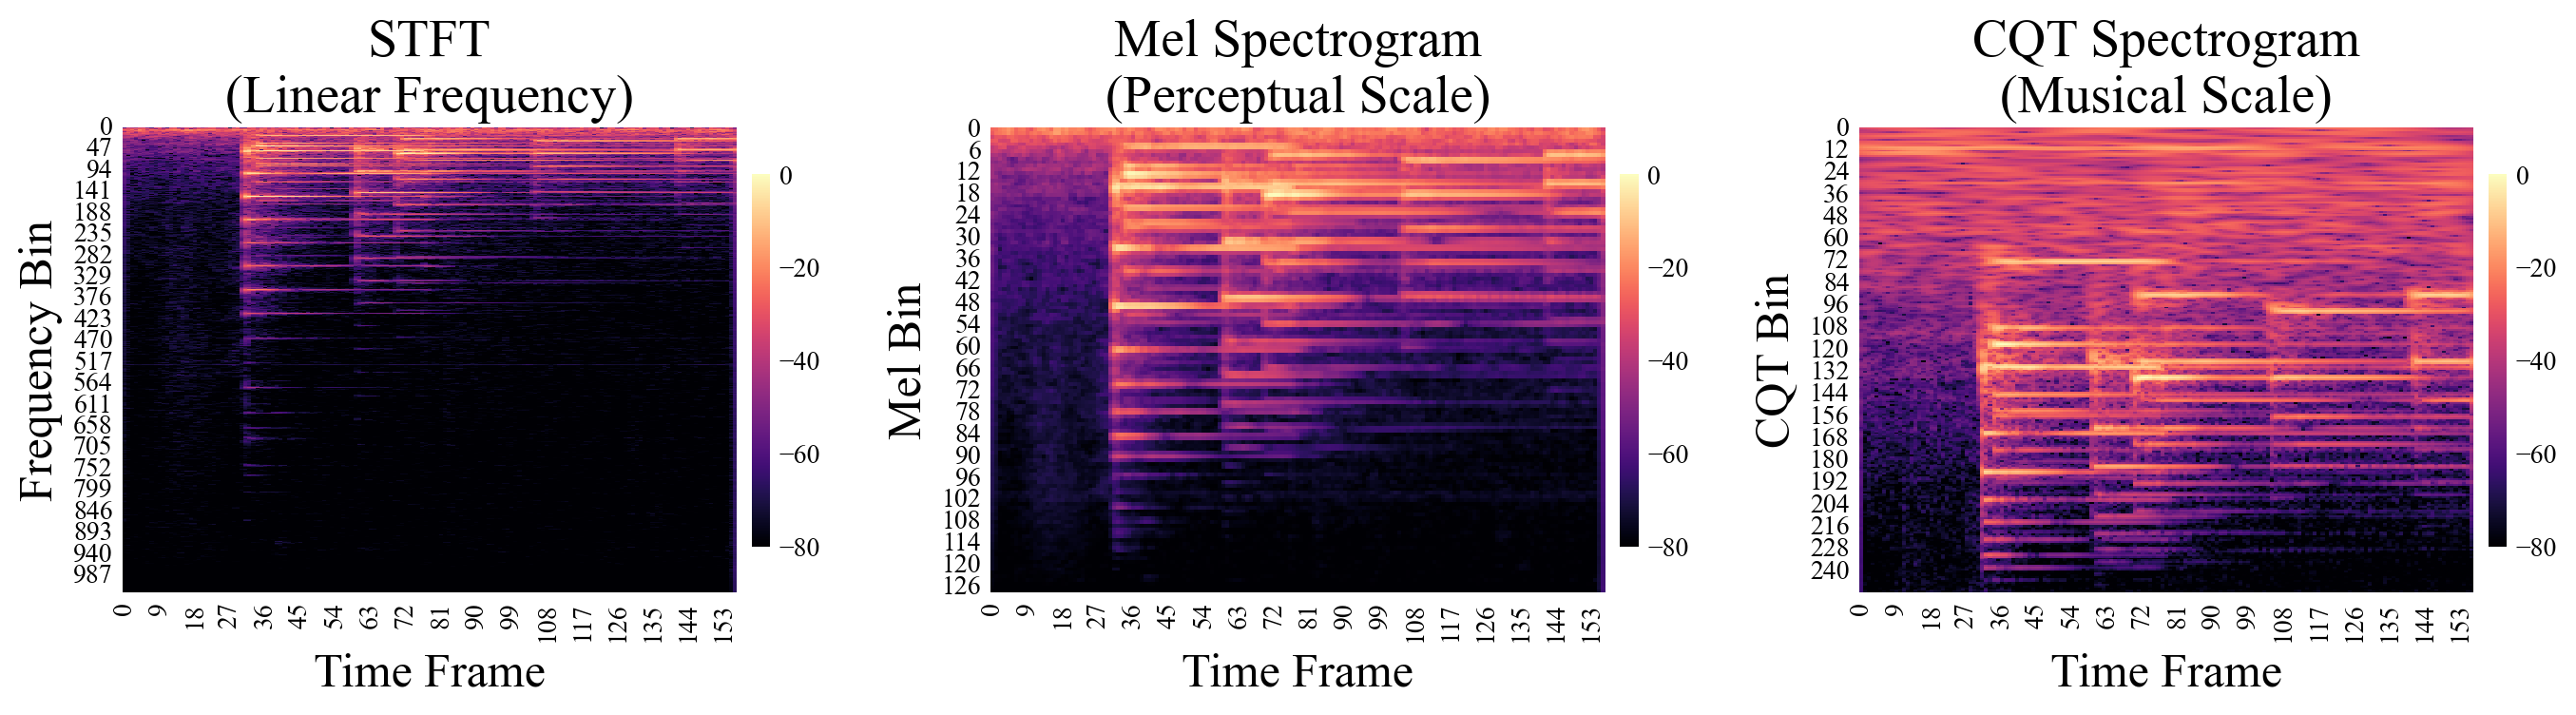

In [37]:
plot_spectograms(audio_path)

Adding noise to the audio, spectrogram visualization

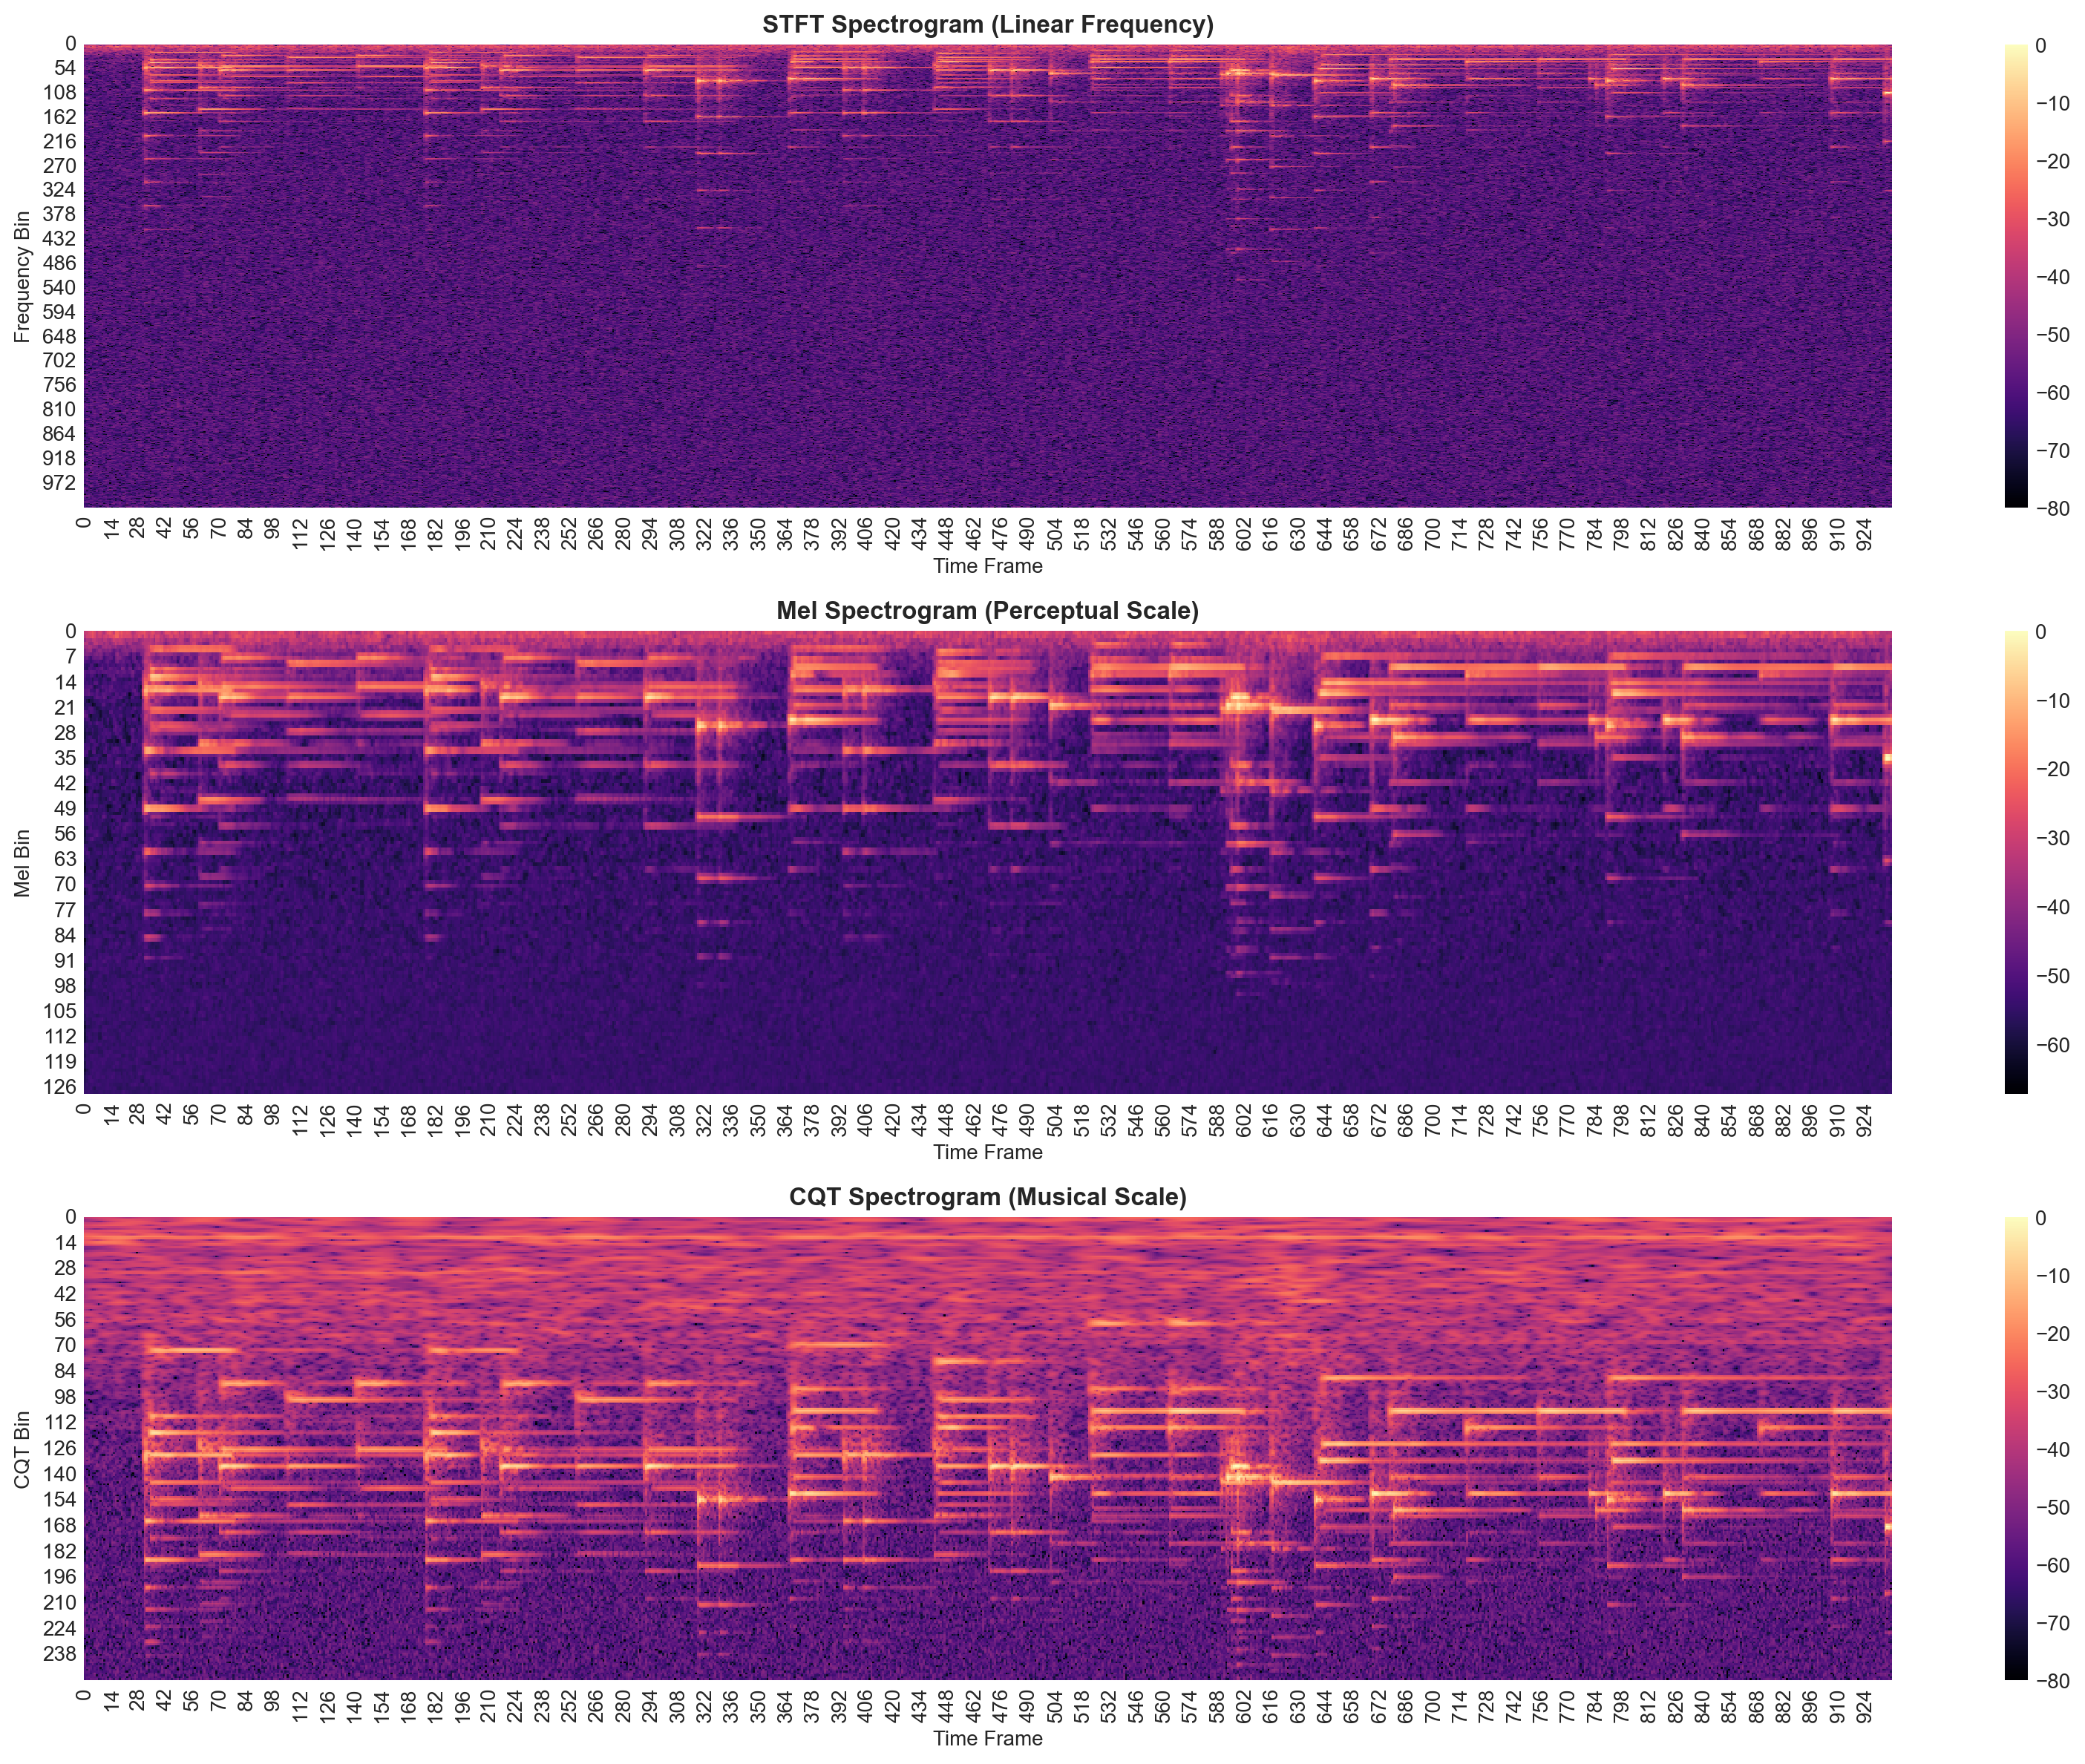


 Spectrogram Interpretation:
- Brighter colors = more energy
- Horizontal bands = sustained notes
- Vertical bands = onsets
- CQT aligns better with piano pitch spacing


In [15]:
plot_spectograms(audio_path, noise_db = 20)

Energy and power visualization

Analyzing frequency content of sample files...


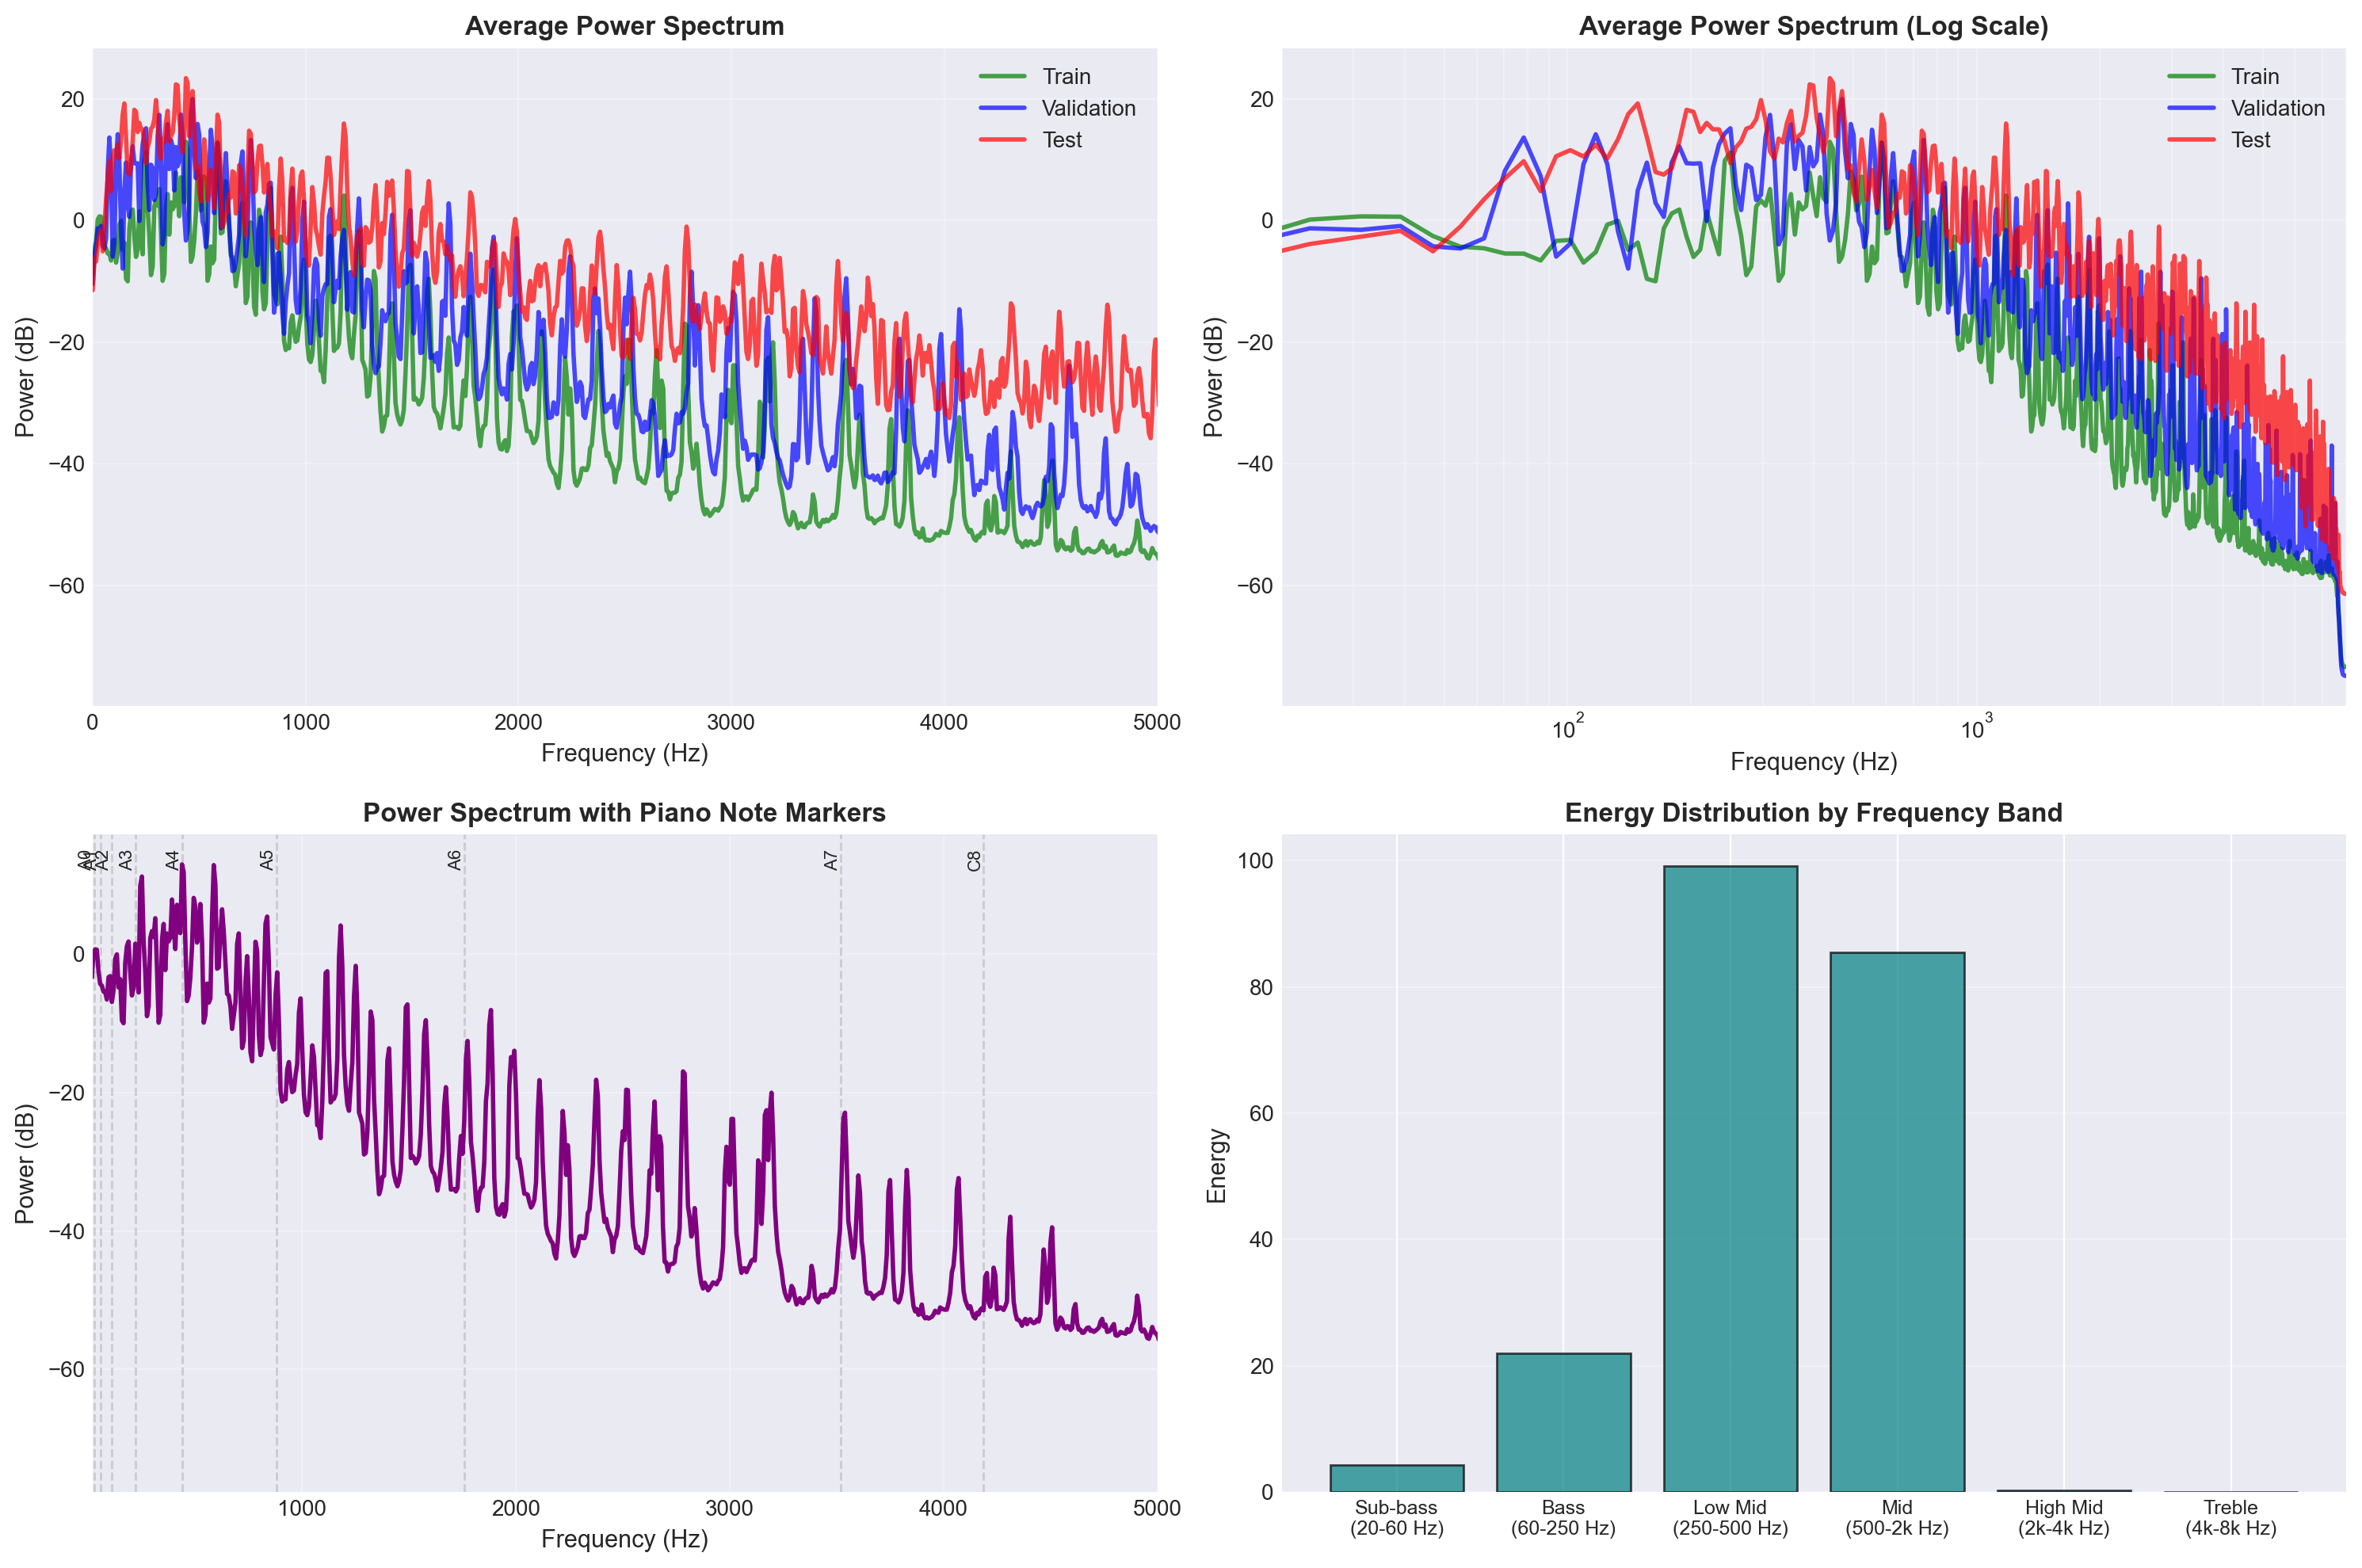


 Key Observations:
- Most energy is in 100-2000 Hz (fundamental frequencies of piano)
- Clear peaks at specific frequencies = notes being played
- Harmonics visible as peaks at multiples of fundamental


In [16]:
# Analyze frequency content across multiple files
print("Analyzing frequency content of sample files...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

all_spectra = []
split_names = []

for sample in sample_files:
    audio_path = maestro_path / sample['audio_filename']
    if audio_path.exists():
        y, sr = librosa.load(audio_path, sr=16000, duration=30)
        
        # Compute power spectrum
        D = librosa.stft(y)
        power = np.abs(D) ** 2
        avg_power = np.mean(power, axis=1)
        freqs = librosa.fft_frequencies(sr=sr)
        
        all_spectra.append(avg_power)
        split_names.append(sample['split'])

# Plot average power spectrum
colors = ['green', 'blue', 'red']
for spectrum, name, color in zip(all_spectra, split_names, colors):
    axes[0, 0].plot(freqs, 10 * np.log10(spectrum + 1e-10), 
                   label=name.capitalize(), linewidth=2, alpha=0.7, color=color)
axes[0, 0].set_xlabel('Frequency (Hz)', fontsize=11)
axes[0, 0].set_ylabel('Power (dB)', fontsize=11)
axes[0, 0].set_title('Average Power Spectrum', fontsize=12, fontweight='bold')
axes[0, 0].set_xlim(0, 5000)  # Focus on piano range
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot in log scale
for spectrum, name, color in zip(all_spectra, split_names, colors):
    axes[0, 1].plot(freqs, 10 * np.log10(spectrum + 1e-10), 
                   label=name.capitalize(), linewidth=2, alpha=0.7, color=color)
axes[0, 1].set_xlabel('Frequency (Hz)', fontsize=11)
axes[0, 1].set_ylabel('Power (dB)', fontsize=11)
axes[0, 1].set_title('Average Power Spectrum (Log Scale)', fontsize=12, fontweight='bold')
axes[0, 1].set_xscale('log')
axes[0, 1].set_xlim(20, 8000)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, which='both')

# Piano frequency range overlay
piano_notes = [
    ('A0', 27.5), ('A1', 55), ('A2', 110), ('A3', 220),
    ('A4', 440), ('A5', 880), ('A6', 1760), ('A7', 3520), ('C8', 4186)
]
for note, freq in piano_notes:
    axes[1, 0].axvline(freq, color='gray', alpha=0.3, linestyle='--', linewidth=1)
    axes[1, 0].text(freq, 0.95, note, rotation=90, fontsize=8, 
                   transform=axes[1, 0].get_xaxis_transform(), ha='right')

# Replot one spectrum with piano notes
axes[1, 0].plot(freqs, 10 * np.log10(all_spectra[0] + 1e-10), 
               linewidth=2, color='purple')
axes[1, 0].set_xlabel('Frequency (Hz)', fontsize=11)
axes[1, 0].set_ylabel('Power (dB)', fontsize=11)
axes[1, 0].set_title('Power Spectrum with Piano Note Markers', fontsize=12, fontweight='bold')
axes[1, 0].set_xlim(20, 5000)
axes[1, 0].grid(alpha=0.3)

# Energy distribution by frequency band
bands = {
    'Sub-bass\n(20-60 Hz)': (20, 60),
    'Bass\n(60-250 Hz)': (60, 250),
    'Low Mid\n(250-500 Hz)': (250, 500),
    'Mid\n(500-2k Hz)': (500, 2000),
    'High Mid\n(2k-4k Hz)': (2000, 4000),
    'Treble\n(4k-8k Hz)': (4000, 8000)
}

band_energies = []
band_labels = []
for label, (low, high) in bands.items():
    mask = (freqs >= low) & (freqs < high)
    energy = np.sum(all_spectra[0][mask])
    band_energies.append(energy)
    band_labels.append(label)

axes[1, 1].bar(range(len(band_energies)), band_energies, 
              color='teal', edgecolor='black', alpha=0.7)
axes[1, 1].set_xticks(range(len(band_labels)))
axes[1, 1].set_xticklabels(band_labels, fontsize=9)
axes[1, 1].set_ylabel('Energy', fontsize=11)
axes[1, 1].set_title('Energy Distribution by Frequency Band', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n Key Observations:")
print("- Most energy is in 100-2000 Hz (fundamental frequencies of piano)")
print("- Clear peaks at specific frequencies = notes being played")
print("- Harmonics visible as peaks at multiples of fundamental")

MIDI Statistics

In [17]:
# Analyze MIDI files
print("Analyzing MIDI files...\n")

midi_stats = []

# Analyze first 100 MIDI files for statistics (full analysis would take too long)
for idx, row in df.head(100).iterrows():
    midi_path = maestro_path / row['midi_filename']
    
    if midi_path.exists():
        try:
            midi = pretty_midi.PrettyMIDI(str(midi_path))
            
            # Count notes
            total_notes = sum(len(instrument.notes) for instrument in midi.instruments)
            
            # Get all note pitches
            pitches = [note.pitch for instrument in midi.instruments 
                      for note in instrument.notes]
            
            # Get all note durations
            durations = [note.end - note.start for instrument in midi.instruments 
                        for note in instrument.notes]
            
            # Get all velocities
            velocities = [note.velocity for instrument in midi.instruments 
                         for note in instrument.notes]
            
            midi_stats.append({
                'split': row['split'],
                'duration': row['duration'],
                'total_notes': total_notes,
                'notes_per_second': total_notes / row['duration'],
                'min_pitch': min(pitches) if pitches else 0,
                'max_pitch': max(pitches) if pitches else 0,
                'avg_pitch': np.mean(pitches) if pitches else 0,
                'avg_duration': np.mean(durations) if durations else 0,
                'avg_velocity': np.mean(velocities) if velocities else 0,
                'pitch_range': max(pitches) - min(pitches) if pitches else 0
            })
        except:
            pass

midi_df = pd.DataFrame(midi_stats)

print("MIDI Statistics (first 100 files):")
print("=" * 60)
print(f"Average notes per recording: {midi_df['total_notes'].mean():.1f}")
print(f"Average notes per second: {midi_df['notes_per_second'].mean():.2f}")
print(f"Average note duration: {midi_df['avg_duration'].mean():.3f} seconds")
print(f"Average velocity: {midi_df['avg_velocity'].mean():.1f} (0-127 scale)")
print(f"Average pitch: {midi_df['avg_pitch'].mean():.1f} (MIDI note number)")
print(f"Average pitch range: {midi_df['pitch_range'].mean():.1f} semitones")

Analyzing MIDI files...

MIDI Statistics (first 100 files):
Average notes per recording: 4545.4
Average notes per second: 9.39
Average note duration: 0.249 seconds
Average velocity: 61.0 (0-127 scale)
Average pitch: 64.8 (MIDI note number)
Average pitch range: 74.8 semitones


Visualization of a piano roll

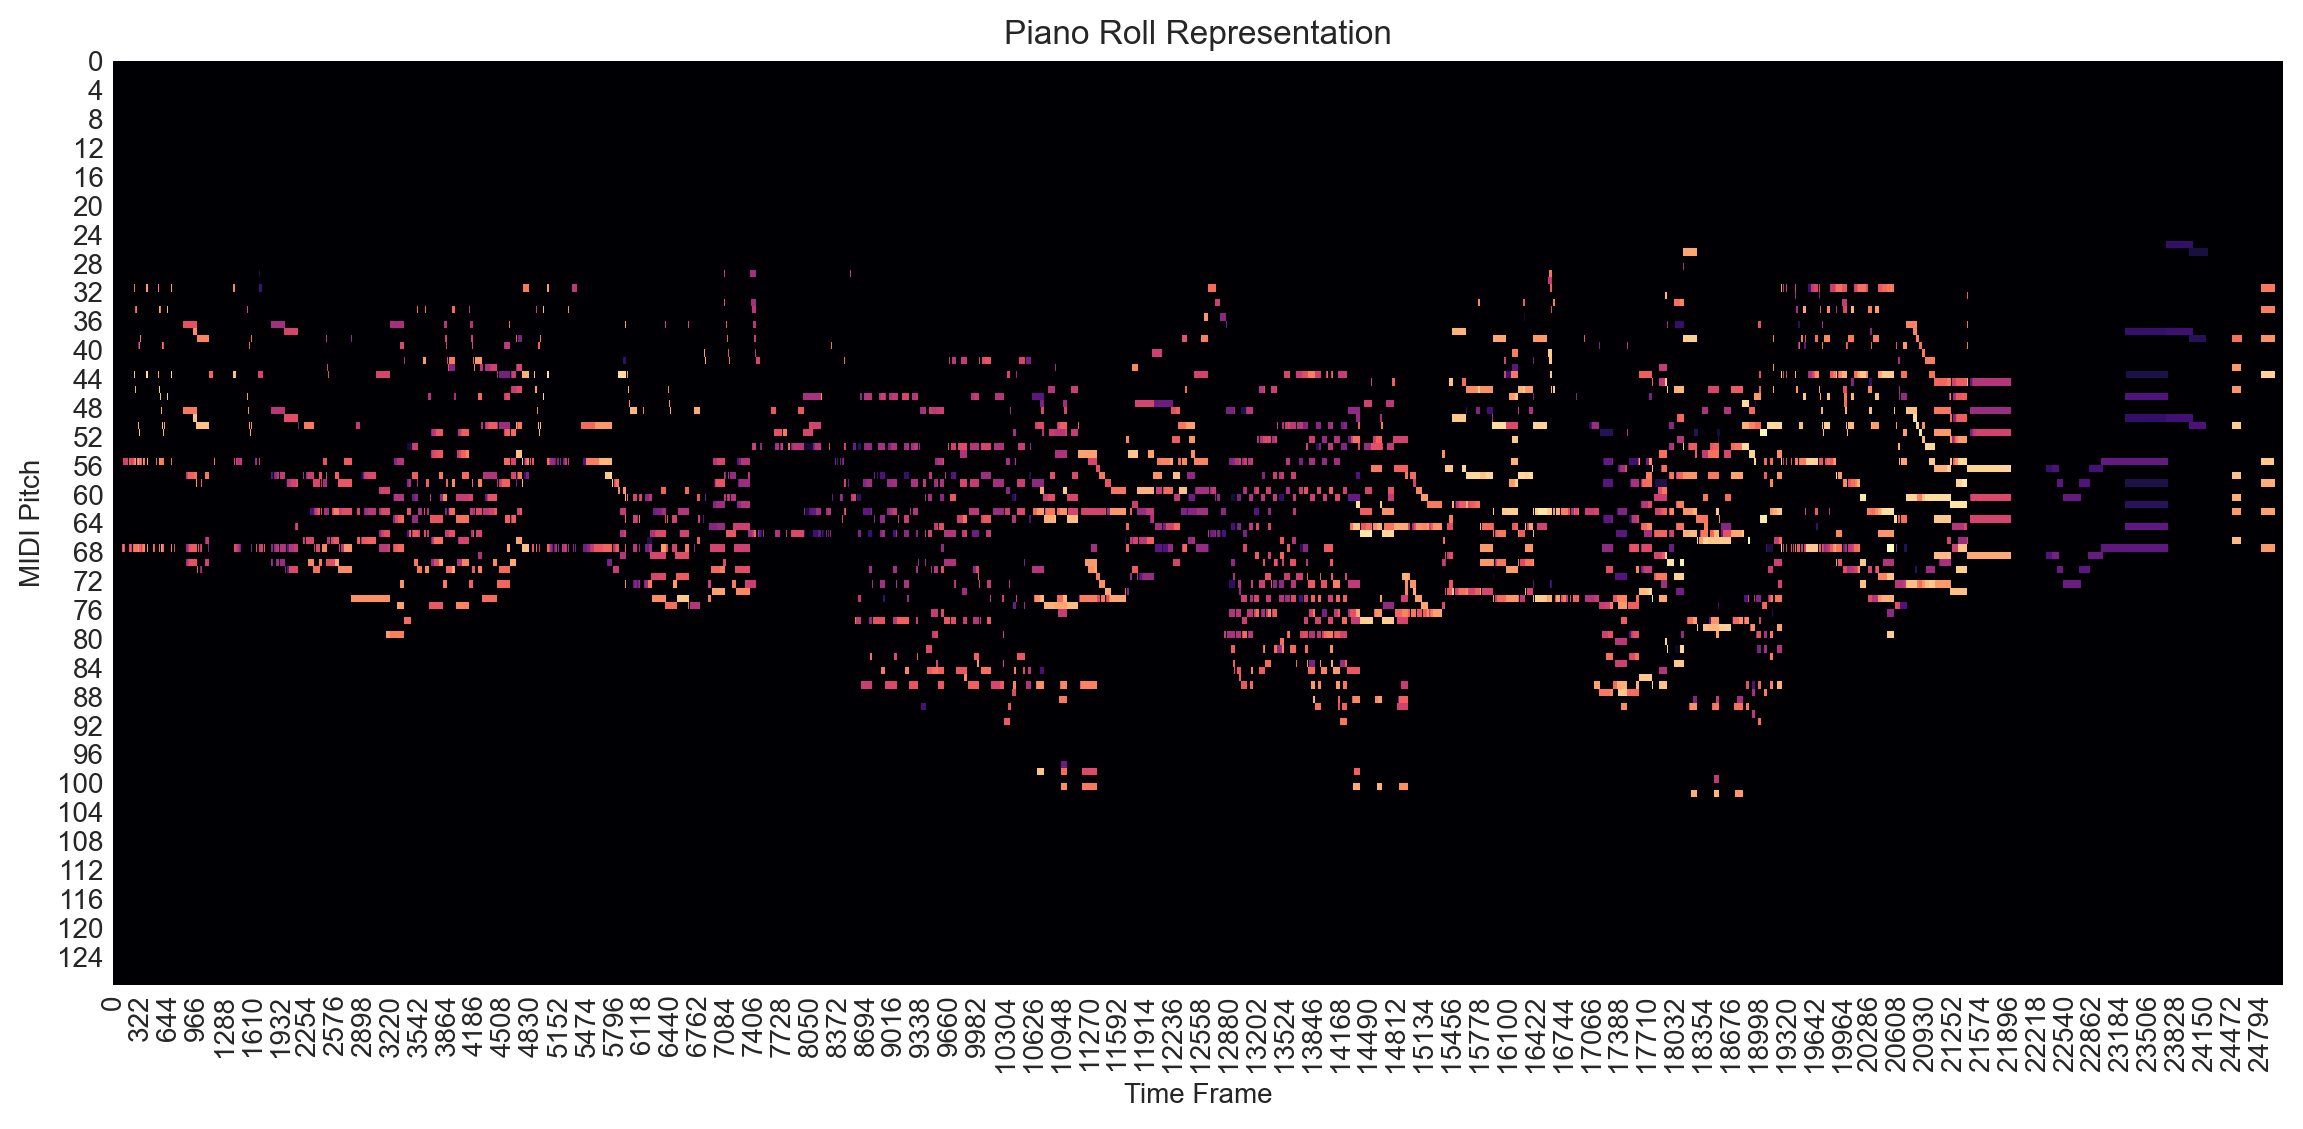

In [ ]:

midi_path = maestro_path / sample['midi_filename']
pm = pretty_midi.PrettyMIDI(str(midi_path))

piano_roll = pm.get_piano_roll(fs=100)  # 100 frames per second

plt.figure(figsize=(14,6))
sns.heatmap(
    piano_roll,
    cmap="magma",
    cbar=False
)

plt.title("Piano Roll Representation")
plt.xlabel("Time Frame")
plt.ylabel("MIDI Pitch")
plt.show()


Example of a note

In [39]:
notes = pm.instruments[0].notes

print("Total notes:", len(notes))

first_note = notes[0]
print("First note:")
print("Pitch:", first_note.pitch)
print("Start:", first_note.start)
print("End:", first_note.end)
print("Velocity:", first_note.velocity)


Total notes: 4435
First note:
Pitch: 67
Start: 1.0552083333333333
End: 1.0947916666666666
Velocity: 70


Pitch distribution

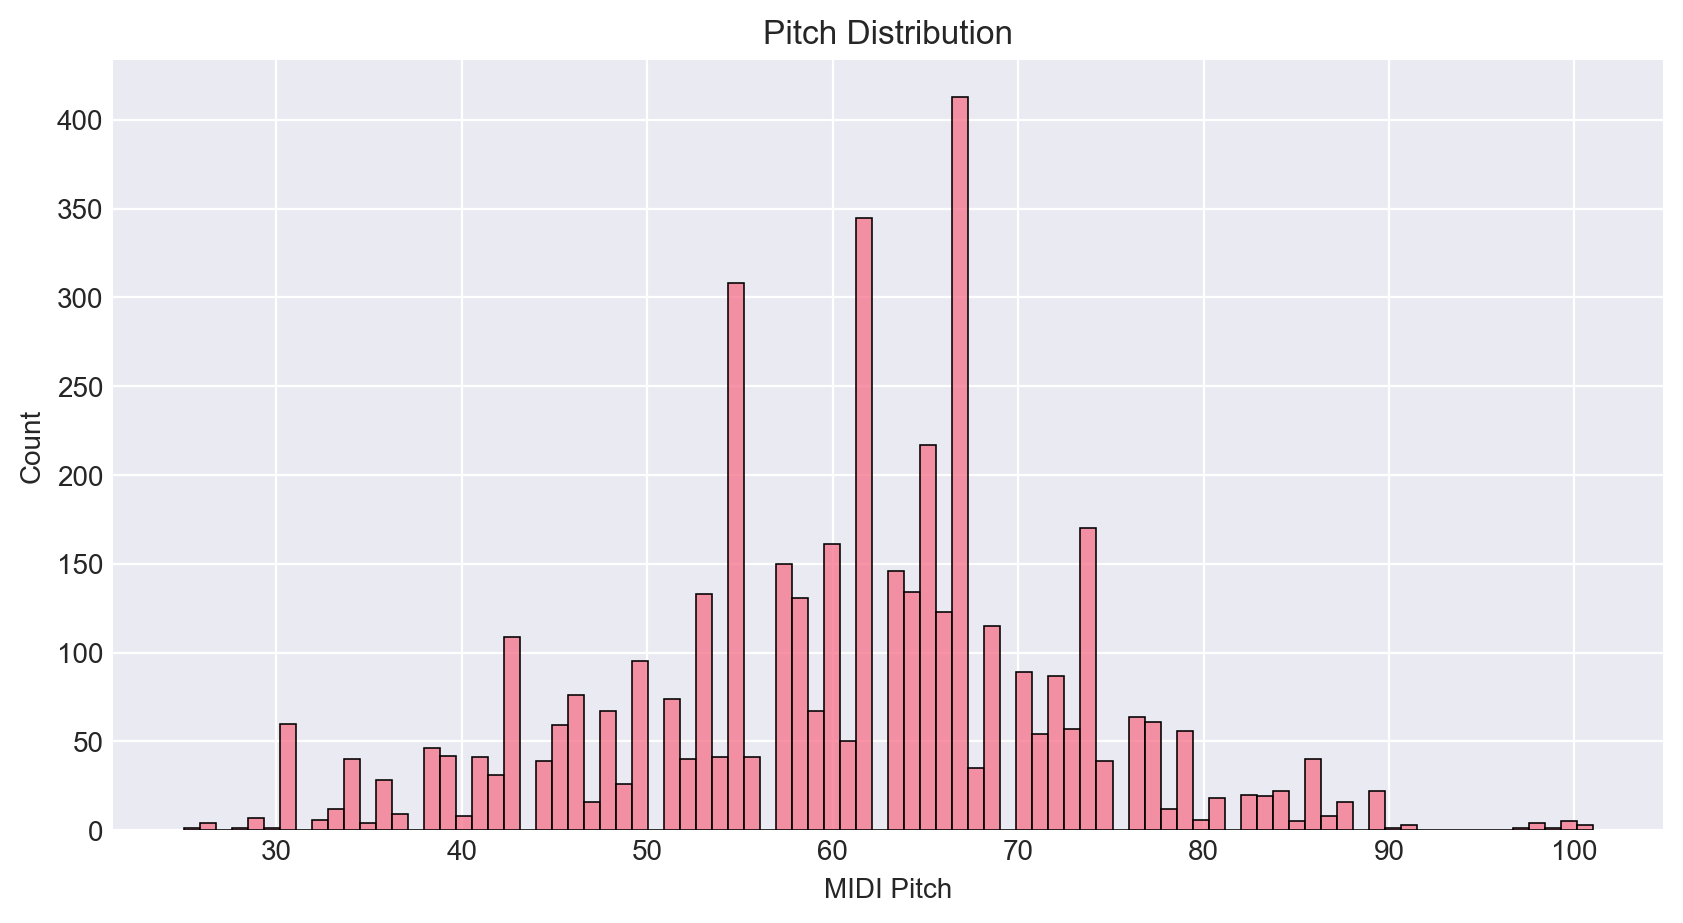

In [ ]:
pitches = [note.pitch for note in notes]

plt.figure(figsize=(10,5))
sns.histplot(pitches, bins=88)
plt.title("Pitch Distribution")
plt.xlabel("MIDI Pitch")
plt.ylabel("Count")
plt.show()


Note Duration Distribution

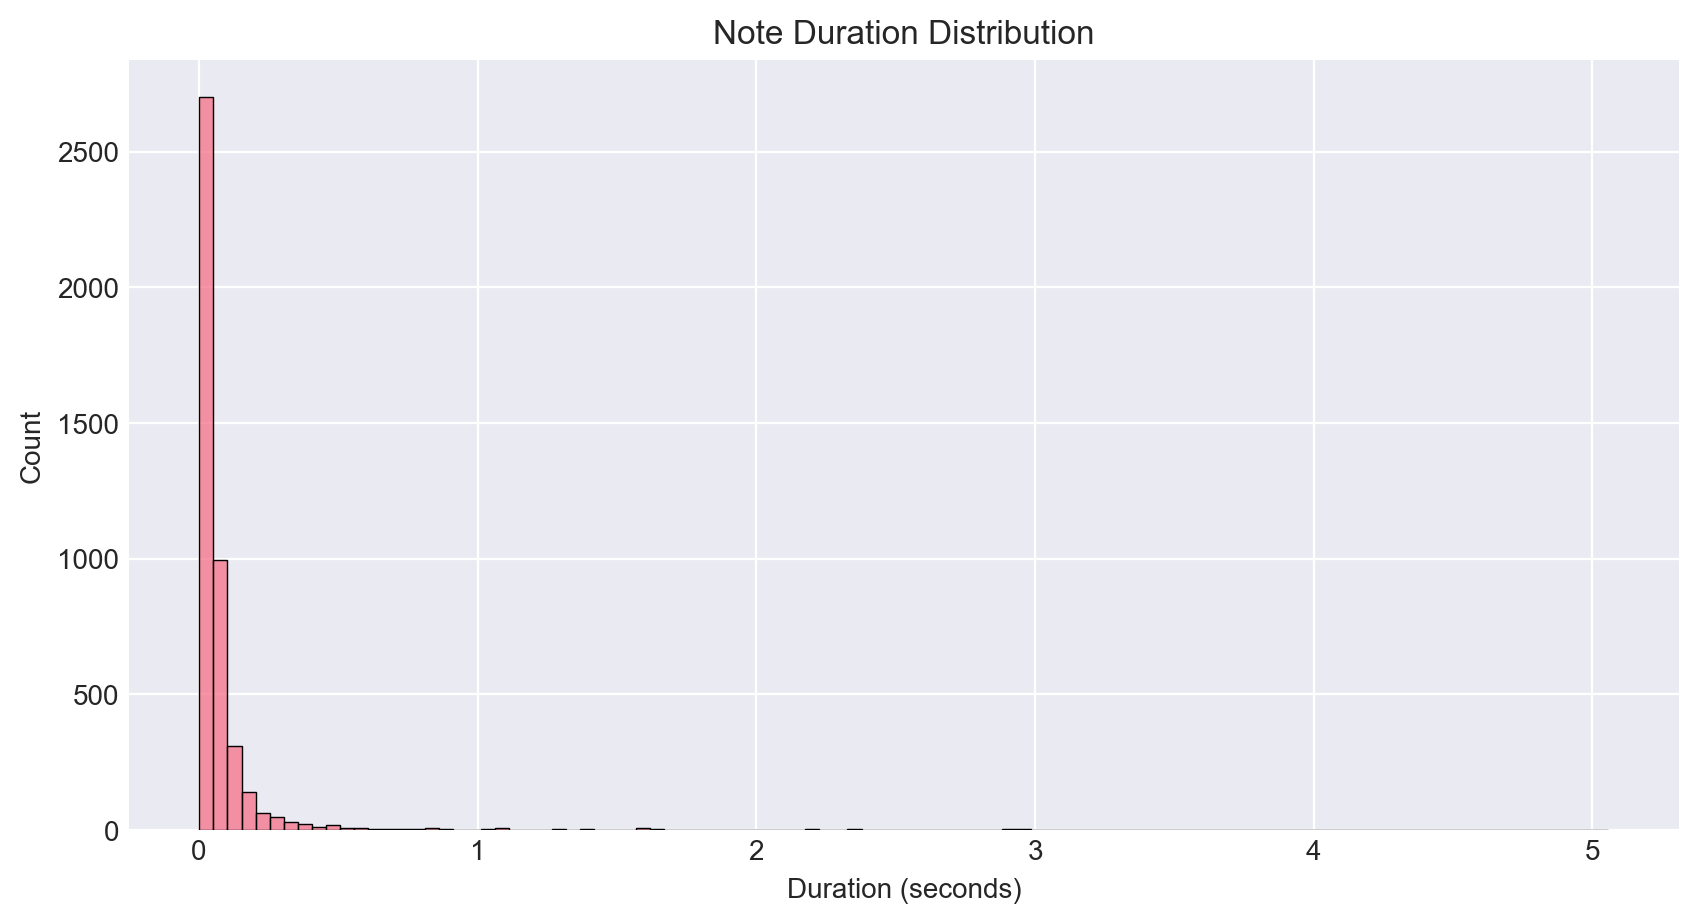

In [44]:
durations = [note.end - note.start for note in notes]

plt.figure(figsize=(10,5))
sns.histplot(durations, bins=100)
plt.title("Note Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.show()


Velocity Distribution

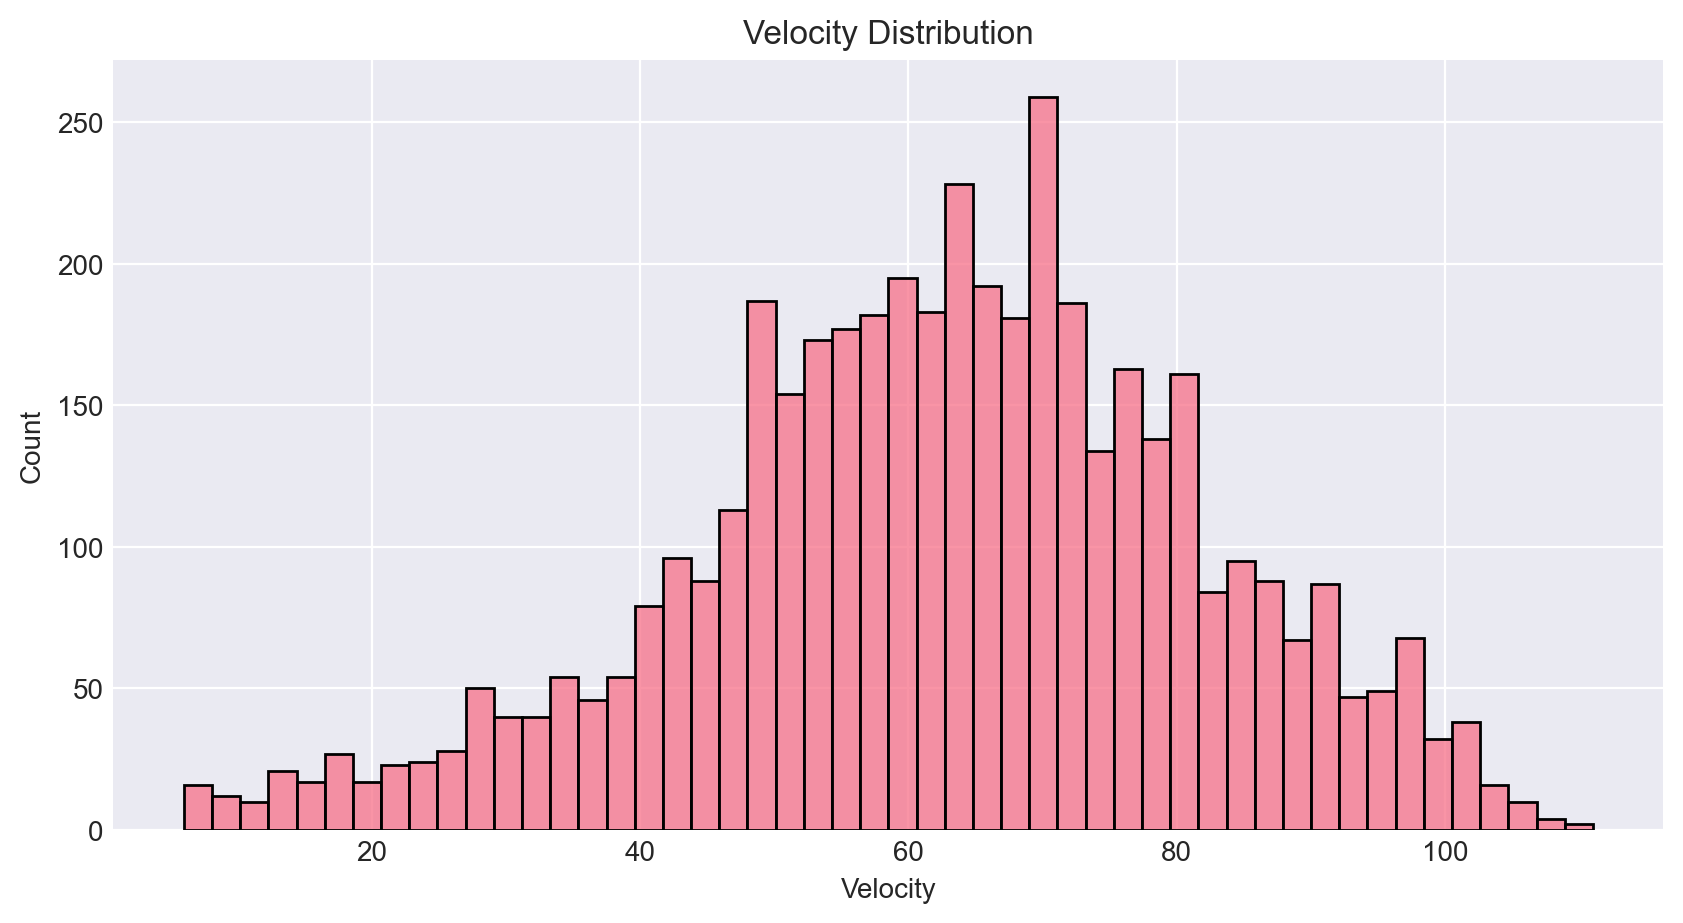

In [45]:
velocities = [note.velocity for note in notes]

plt.figure(figsize=(10,5))
sns.histplot(velocities, bins=50)
plt.title("Velocity Distribution")
plt.xlabel("Velocity")
plt.show()


In [52]:
piano_roll = pm.get_piano_roll(fs=100)
polyphony = (piano_roll > 0).sum(axis=0)

print("Maximum polyphony:", polyphony.max())
print("Mean polyphony:", polyphony.mean())
print("Median polyphony:", np.median(polyphony))
print("95th percentile:", np.percentile(polyphony, 95))


Maximum polyphony: 21
Mean polyphony: 4.766584178175142
Median polyphony: 4.0
95th percentile: 11.0


Midi variables

In [ ]:
import pretty_midi
from pathlib import Path

MIDI_PATH = "/Users/miguel/Desktop/TFG/TFG_Automatic_Music_Transcription/data/raw/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi"

pm = pretty_midi.PrettyMIDI(MIDI_PATH)

print("="*60)
print("GLOBAL INFORMATION")
print("="*60)

print("Total duration (seconds):", pm.get_end_time())
print("Number of instruments:", len(pm.instruments))

# ---------------------------------------------------
# Tempo Changes
# ---------------------------------------------------

print("\nTempo Changes:")
times, tempi = pm.get_tempo_changes()
for t, tempo in zip(times[:10], tempi[:10]):
    print(f"  Time {t:.3f}s → {tempo:.2f} BPM")

# ---------------------------------------------------
# Time Signatures
# ---------------------------------------------------

print("\nTime Signatures:")
for ts in pm.time_signature_changes:
    print(f"  Time {ts.time:.3f}s → {ts.numerator}/{ts.denominator}")

# ---------------------------------------------------
# Key Signatures
# ---------------------------------------------------

print("\nKey Signatures:")
for ks in pm.key_signature_changes:
    print(f"  Time {ks.time:.3f}s → key number {ks.key_number}")


print("\nDone.")

GLOBAL INFORMATION
Total duration (seconds): 969.0208333333334
Number of instruments: 1

Tempo Changes:
  Time 0.000s → 120.00 BPM

Time Signatures:
  Time 0.000s → 4/4

Key Signatures:

INSTRUMENT DETAILS

Instrument 0
  Name: 
  Program: 0
  Is drum: False
  Total notes: 7894
  Total control changes: 13725
  Total pitch bends: 0

  First 5 notes:
    Start: 1.093, End: 1.190, Pitch: 71, Velocity: 60
    Start: 1.279, End: 1.497, Pitch: 55, Velocity: 44
    Start: 1.464, End: 1.631, Pitch: 59, Velocity: 55
    Start: 1.633, End: 1.753, Pitch: 62, Velocity: 52
    Start: 1.289, End: 1.794, Pitch: 71, Velocity: 54

  Sustain pedal events (first 10):
    Time 0.000s → DOWN (value=110)
    Time 0.510s → DOWN (value=114)
    Time 0.608s → DOWN (value=118)
    Time 0.959s → DOWN (value=122)
    Time 1.232s → DOWN (value=111)
    Time 1.252s → DOWN (value=93)
    Time 1.270s → DOWN (value=76)
    Time 1.290s → DOWN (value=65)
    Time 1.310s → UP (value=60)
    Time 1.350s → DOWN (value=66)


In [ ]:
# ---------------------------------------------------
# Instruments


print("\nINSTRUMENT DETAILS")
print("="*60)

for inst_idx, instrument in enumerate(pm.instruments):

    print(f"\nInstrument {inst_idx}")
    print("  Name:", instrument.name)
    print("  Program:", instrument.program)
    print("  Is drum:", instrument.is_drum)

    print("  Total notes:", len(instrument.notes))
    print("  Total control changes:", len(instrument.control_changes))
    print("  Total pitch bends:", len(instrument.pitch_bends))

    # ---------------------------------------------------
    # First 5 Notes
    # ---------------------------------------------------

    print("\n  First 5 notes:")
    for note in instrument.notes[:5]:
        print(f"    Start: {note.start:.3f}, "
              f"End: {note.end:.3f}, "
              f"Pitch: {note.pitch}, "
              f"Velocity: {note.velocity}")

    # ---------------------------------------------------
    # Sustain Pedal (CC 64)
    # ---------------------------------------------------

    sustain_cc = [cc for cc in instrument.control_changes if cc.number == 64]

    print("\n  Sustain pedal events (first 10):")
    for cc in sustain_cc[:10]:
        state = "DOWN" if cc.value >= 64 else "UP"
        print(f"    Time {cc.time:.3f}s → {state} (value={cc.value})")

    # ---------------------------------------------------
    # Soft Pedal (CC 67)
    # ---------------------------------------------------

    soft_cc = [cc for cc in instrument.control_changes if cc.number == 67]

    print("\n  Soft pedal events:")
    for cc in soft_cc[:5]:
        state = "ON" if cc.value >= 64 else "OFF"
        print(f"    Time {cc.time:.3f}s → {state}")

    # ---------------------------------------------------
    # Sostenuto (CC 66)
    # ---------------------------------------------------

    sost_cc = [cc for cc in instrument.control_changes if cc.number == 66]

    print("\n  Sostenuto pedal events:")
    for cc in sost_cc[:5]:
        state = "ON" if cc.value >= 64 else "OFF"
        print(f"    Time {cc.time:.3f}s → {state}")

    # ---------------------------------------------------
    # Pitch Bends
    # ---------------------------------------------------

    print("\n  First 5 pitch bends:")
    for pb in instrument.pitch_bends[:5]:
        print(f"    Time {pb.time:.3f}s → value={pb.pitch}")



INSTRUMENT DETAILS

Instrument 0
  Name: 
  Program: 0
  Is drum: False
  Total notes: 7894
  Total control changes: 13725
  Total pitch bends: 0

  First 5 notes:
    Start: 1.093, End: 1.190, Pitch: 71, Velocity: 60
    Start: 1.279, End: 1.497, Pitch: 55, Velocity: 44
    Start: 1.464, End: 1.631, Pitch: 59, Velocity: 55
    Start: 1.633, End: 1.753, Pitch: 62, Velocity: 52
    Start: 1.289, End: 1.794, Pitch: 71, Velocity: 54

  Sustain pedal events (first 10):
    Time 0.000s → DOWN (value=110)
    Time 0.510s → DOWN (value=114)
    Time 0.608s → DOWN (value=118)
    Time 0.959s → DOWN (value=122)
    Time 1.232s → DOWN (value=111)
    Time 1.252s → DOWN (value=93)
    Time 1.270s → DOWN (value=76)
    Time 1.290s → DOWN (value=65)
    Time 1.310s → UP (value=60)
    Time 1.350s → DOWN (value=66)

  Soft pedal events:
    Time 0.000s → ON
    Time 0.686s → ON
    Time 1.131s → ON
    Time 1.189s → ON
    Time 1.291s → ON

  Sostenuto pedal events:

  First 5 pitch bends:


In [3]:
# ---------------------------------------------------
# Sustain Pedal (CC 64)
# ---------------------------------------------------

sustain_cc = [cc for cc in instrument.control_changes if cc.number == 64]

print("\n  Sustain pedal events (first 10):")
for cc in sustain_cc[:10]:
    state = "DOWN" if cc.value >= 64 else "UP"
    print(f"    Time {cc.time:.3f}s → {state} (value={cc.value})")

# ---------------------------------------------------
# Soft Pedal (CC 67)
# ---------------------------------------------------

soft_cc = [cc for cc in instrument.control_changes if cc.number == 67]

print("\n  Soft pedal events:")
for cc in soft_cc[:5]:
    state = "ON" if cc.value >= 64 else "OFF"
    print(f"    Time {cc.time:.3f}s → {state}")

# ---------------------------------------------------
# Sostenuto (CC 66)
# ---------------------------------------------------

sost_cc = [cc for cc in instrument.control_changes if cc.number == 66]

print("\n  Sostenuto pedal events:")
for cc in sost_cc[:5]:
    state = "ON" if cc.value >= 64 else "OFF"
    print(f"    Time {cc.time:.3f}s → {state}")

# ---------------------------------------------------
# Pitch Bends
# ---------------------------------------------------

print("\n  First 5 pitch bends:")
for pb in instrument.pitch_bends[:5]:
    print(f"    Time {pb.time:.3f}s → value={pb.pitch}")


  Sustain pedal events (first 10):
    Time 0.000s → DOWN (value=110)
    Time 0.510s → DOWN (value=114)
    Time 0.608s → DOWN (value=118)
    Time 0.959s → DOWN (value=122)
    Time 1.232s → DOWN (value=111)
    Time 1.252s → DOWN (value=93)
    Time 1.270s → DOWN (value=76)
    Time 1.290s → DOWN (value=65)
    Time 1.310s → UP (value=60)
    Time 1.350s → DOWN (value=66)

  Soft pedal events:
    Time 0.000s → ON
    Time 0.686s → ON
    Time 1.131s → ON
    Time 1.189s → ON
    Time 1.291s → ON

  Sostenuto pedal events:

  First 5 pitch bends:


In [4]:
def extend_sustain(pm):

    for inst in pm.instruments:

        sustain_events = [cc for cc in inst.control_changes if cc.number == 64]
        sustain_events.sort(key=lambda x: x.time)

        sustain_on = False
        sustain_start = None
        intervals = []

        for cc in sustain_events:
            if cc.value >= 64 and not sustain_on:
                sustain_on = True
                sustain_start = cc.time
            elif cc.value < 64 and sustain_on:
                sustain_on = False
                intervals.append((sustain_start, cc.time))

        if sustain_on:
            intervals.append((sustain_start, pm.get_end_time()))

        for note in inst.notes:
            for start, end in intervals:
                if note.end >= start and note.end <= end:
                    print(f"Extending note {note.pitch} "
                          f"from {note.end:.3f} to {end:.3f}")
                    note.end = end

    return pm

In [5]:
pm_extended = extend_sustain(pm)

Extending note 71 from 1.190 to 1.310
Extending note 55 from 1.497 to 2.032
Extending note 59 from 1.631 to 2.032
Extending note 62 from 1.753 to 2.032
Extending note 71 from 1.794 to 2.032
Extending note 72 from 1.828 to 2.032
Extending note 67 from 2.000 to 2.032
Extending note 74 from 3.448 to 3.819
Extending note 71 from 3.602 to 3.819
Extending note 74 from 3.806 to 3.819
Extending note 59 from 3.967 to 4.209
Extending note 78 from 4.026 to 4.209
Extending note 79 from 4.200 to 4.209
Extending note 60 from 4.333 to 4.561
Extending note 76 from 4.343 to 4.561
Extending note 79 from 4.521 to 4.561
Extending note 74 from 4.684 to 4.858
Extending note 59 from 4.705 to 4.858
Extending note 48 from 9.792 to 10.101
Extending note 67 from 9.890 to 10.101
Extending note 66 from 10.030 to 10.101
Extending note 57 from 10.101 to 10.101
Extending note 67 from 10.593 to 10.811
Extending note 69 from 10.636 to 10.811
Extending note 50 from 10.793 to 10.811
Extending note 60 from 13.104 to 13.73